In [2]:
#!/bin/env python3

import os, re
import bids
from nilearn import image as nimg
from nilearn import plotting as nplot
from nilearn.plotting import plot_design_matrix
import nilearn.glm.first_level
import pandas as pd
import numpy as np
import logging
import argparse
import glob

In [3]:
#set your paths
task='epiproj'
basedir = os.path.join("/home/jovyan/panmvpa")
funcdir = os.path.join(basedir, "ds006598-download/sub-PAN01/ses-1/func")
func_files = glob.glob(os.path.join(funcdir,'*%s*.nii.gz' %task))

In [4]:
#append data for fixed effects model
design_matrices = []
fmri_img = []
masks = []
func_tr = 1.355
#confound_vars = ['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']
#confound_vars += ["cosine%02i" % (i,) for i in range(3)]

In [4]:
func_img = nimg.load_img(func_files)
fmri_img.append(func_img)

In [5]:
#read fmri volumes in seconds
frame_times = np.arange(func_img.shape[-1]) * func_tr

In [5]:
stimdir = os.path.join(basedir, "ds006598-download/derivatives/afni_timing/PAN01")
glob.glob(os.path.join(stimdir, '*ses-1*epiproj*'))
#eventsfile = os.path.join(stimdir,'ses1_epiproj_3col.txt')
#header = ["onset", "duration","trial_type"]
#events = pd.read_table(eventsfile, names=header, header=0)

['/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_futurenonself.1D',
 '/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_futureself.1D',
 '/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_presentself.1D',
 '/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_presentnonself.1D',
 '/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_pastself.1D',
 '/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/sub-PAN01_ses-1_task-epiproj_pastnonself.1D']

In [7]:
design = nilearn.glm.first_level.make_first_level_design_matrix(frame_times, events,drift_model=None,high_pass=0.01,hrf_model='spm')
design_matrices.append(design)

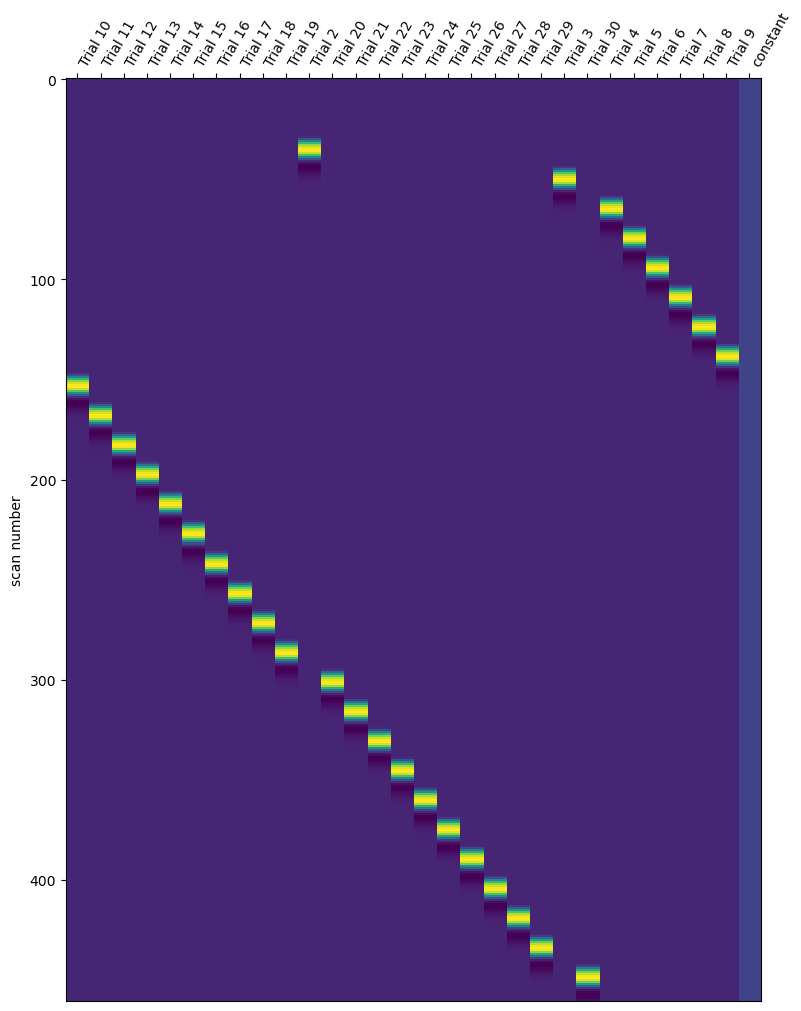

In [8]:
designplot = plot_design_matrix(design_matrices)
#design.to_csv(os.path.join(stimdir,"PAN01_ses1_epiproj_design.csv"))

In [9]:
#setup basic contrasts
contrast_matrix = np.eye(design.shape[1])
basic_contrasts = dict([(column, contrast_matrix[i]) for i, column in enumerate(design.columns)])
#print(basic_contrasts)
basic_contrasts['Trial 10']

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [10]:
fmri_glm = nilearn.glm.first_level.FirstLevelModel(n_jobs=8,smoothing_fwhm=4, t_r=func_tr)
#fmri_glm = fmri_glm.fit(func_img,design_matrices=design)
fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)
report = fmri_glm.generate_report(basic_contrasts['Trial 10'])
report.save_as_html(os.path.join(basedir,'PAN01_epiproj_trialev/report.html'))

/tmp/ipykernel_5634/2436613978.py:3: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)


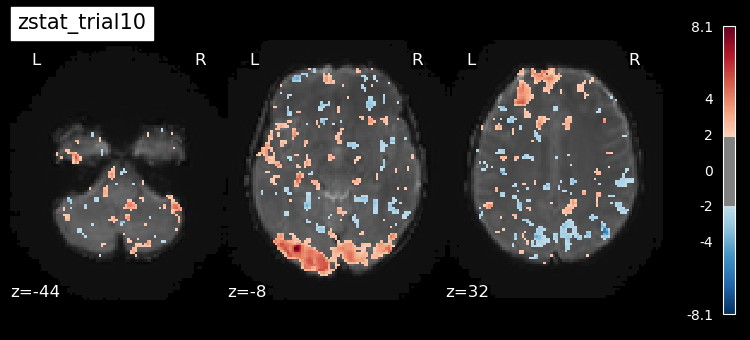

In [11]:
##saves contrasts to nii files and generates plots#
z_map = fmri_glm.compute_contrast(basic_contrasts['Trial 10'], output_type='z_score')
z_image_path = os.path.join(basedir,'PAN01_epiproj_trialev/zmap10.nii.gz')
z_map.to_filename(z_image_path)
bg_img = nimg.mean_img(func_img)
display=nplot.plot_stat_map(z_map, bg_img=bg_img, threshold=2.0, title="zstat_trial10", display_mode='z', cut_coords=3, black_bg=True)
display.savefig(os.path.join(basedir,'PAN01_epiproj_trialev/zmap10.png'))